In [1]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "64"
os.environ["OMP_NUM_THREADS"] = "64"
os.environ["MKL_NUM_THREADS"] = "64"

In [2]:
import re
import warnings

import numpy as np
import pandas as pd

from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import mean_absolute_error, median_absolute_error, r2_score, silhouette_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.colors import LogNorm

warnings.filterwarnings('ignore')

RANDOM_STATE = 42

In [3]:
df = pd.read_parquet('data/strings-embedded-TFIDF.parquet')
df.head()

,JobID,SubmitLine_TFIDF,WorkDir_TFIDF
0,1861200,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1699143708022036, 0.0849571854011018, 0.0, ..."
1,1861200.batch,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,2054579,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.07932290597715051, 0.039661452988575256, 0...."
3,2054580,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.07923656198399216, 0.03961828099199608, 0.0..."
4,2054581,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.08059262585395598, 0.04029631292697799, 0.0..."


In [4]:
tdf = pd.read_parquet("data/slurm-preprocessed.parquet")
tdf.head()

,Account,AllocCPUS,AllocNodes,AllocTRES,AssocID,AveCPU,AveCPUFreq,AveDiskRead,AveDiskWrite,AvePages,...,TRESUsageOutMinTask,TRESUsageOutTot,UID,User,UserCPU,WorkDir,JobID_base,JobID_suffix,JobID_step,JobID_type
0,default,60,2,"billing=60,cpu=60,mem=1600G,node=2",1654,<NA>,<NA>,NaN,NaN,<NA>,...,None,None,406601040.0,40311488,6,/mnt/scratch2/users/40311488,1861200,None,None,X (Normal)
1,default,1,1,"cpu=1,mem=800G,node=1",1654,0,2500000,77.845635,1.319541,2166680,...,fs/disk=0,"energy=294,fs/disk=1416846876",NaN,None,6,None,1861200,None,None,X.batch (Normal Batch)
2,default,56,1,"billing=56,cpu=56,mem=900G,node=1",1883,<NA>,<NA>,NaN,NaN,<NA>,...,None,None,406601291.0,40258564,0,/mnt/scratch2/users/40258564/C_I_Ionisation/n1...,2054579,None,None,X (Normal)
3,default,56,1,"billing=56,cpu=56,mem=900G,node=1",1883,<NA>,<NA>,NaN,NaN,<NA>,...,None,None,406601291.0,40258564,0,/mnt/scratch2/users/40258564/C_I_Ionisation/n1...,2054580,None,None,X (Normal)
4,default,56,1,"billing=56,cpu=56,mem=900G,node=1",1883,<NA>,<NA>,NaN,NaN,<NA>,...,None,None,406601291.0,40258564,0,/mnt/scratch2/users/40258564/C_I_Ionisation/n1...,2054581,None,None,X (Normal)


In [5]:
merged_df = pd.merge(
    df, tdf[['Partition', 'State', 'ElapsedRaw', 'JobID_base']],
    left_index=True, right_index=True, how='inner'
)
merged_df = merged_df[['Partition', 'SubmitLine_TFIDF', 'WorkDir_TFIDF', 'State', 'ElapsedRaw', 'JobID']]

n_before_partition = len(merged_df)
merged_df = merged_df[merged_df['Partition'].isin(['k2-lowpri', 'k2-epsrc', 'k2-medpri', 'k2-hipri'])]
n_before_state = len(merged_df)
merged_df = merged_df[merged_df['State'] == 'COMPLETED']

print(f"After merge: {n_before_partition} rows")
print(f"After partition filter: {n_before_state} rows")
print(f"After COMPLETED filter: {len(merged_df)} rows")

After merge: 10888402 rows
After partition filter: 9767299 rows
After COMPLETED filter: 8474107 rows


In [6]:
task_mask = ~merged_df['JobID'].str.contains(r'\.', na=False)
merged_df = merged_df[task_mask]
merged_df = merged_df[~merged_df['JobID'].str.contains(r'\[', na=False)]
merged_df = merged_df.reset_index(drop=True)  # important, see note below
merged_df

,Partition,SubmitLine_TFIDF,WorkDir_TFIDF,State,ElapsedRaw,JobID
0,k2-lowpri,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.07932290597715051, 0.039661452988575256, 0....",COMPLETED,540989,2054579
1,k2-lowpri,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.07923656198399216, 0.03961828099199608, 0.0...",COMPLETED,532023,2054580
2,k2-lowpri,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.08059262585395598, 0.04029631292697799, 0.0...",COMPLETED,567010,2054581
3,k2-lowpri,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0805020735873016, 0.0402510367936508, 0.082...",COMPLETED,600968,2054582
4,k2-lowpri,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.08015829565391351, 0.040079147826956756, 0....",COMPLETED,586590,2054583
...,...,...,...,...,...,...
3623826,k2-hipri,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.06976358844869626, 0.03488179422434813, 0.0...",COMPLETED,525,7598871
3623827,k2-hipri,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.07236073384391795, 0.03618036692195897, 0.0...",COMPLETED,808,7598872
3623828,k2-hipri,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.07194006602607038, 0.03597003301303519, 0.0...",COMPLETED,1440,7598873
3623829,k2-hipri,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.07257826637696474, 0.03628913318848237, 0.0...",COMPLETED,1468,7598874


In [7]:
X_combined = np.hstack((
    np.vstack(merged_df['SubmitLine_TFIDF'].values),
    np.vstack(merged_df['WorkDir_TFIDF'].values)
))
print(f"Final feature matrix shape: {X_combined.shape}")

Final feature matrix shape: (3623831, 1000)


In [8]:
y = merged_df['ElapsedRaw'].astype(float).values

In [9]:
X_train_raw, X_test_raw, y_train, y_test, idx_train, idx_test = train_test_split(
    X_combined, y, merged_df.index, test_size=0.2, random_state=RANDOM_STATE
)

svd = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
X_train = svd.fit_transform(X_train_raw)
X_test = svd.transform(X_test_raw)

variance_retained = svd.explained_variance_ratio_.sum()
print(f"Information retained (train-fit SVD): {variance_retained * 100:.2f}%")

Information retained (train-fit SVD): 92.14%


In [10]:
for k in [25, 50, 100, 200, 500]:
    svd_k = TruncatedSVD(n_components=k, random_state=RANDOM_STATE)
    svd_k.fit(X_train_raw)
    print(f"k={k}: {svd_k.explained_variance_ratio_.sum()*100:.2f}% variance retained")

k=25: 65.40% variance retained
k=50: 81.64% variance retained
k=100: 92.14% variance retained
k=200: 97.25% variance retained
k=500: 99.88% variance retained


In [11]:
N_CLUSTERS = 8

sample_size = min(100000, X_train.shape[0])
sample_indices = np.random.choice(X_train.shape[0], size=sample_size, replace=False)
X_train_sample = X_train[sample_indices]

In [12]:
kmeans = MiniBatchKMeans(
    n_clusters=N_CLUSTERS, 
    random_state=RANDOM_STATE, 
    n_init=10, 
    batch_size=2048
)

In [13]:
from threadpoolctl import threadpool_limits

X_train_sample_clean = np.ascontiguousarray(X_train_sample, dtype=np.float32)
with threadpool_limits(limits=16, user_api='blas'):
    with threadpool_limits(limits=16, user_api='openmp'):
        kmeans.fit(X_train_sample_clean)

In [14]:
X_train_clean = np.ascontiguousarray(X_train, dtype=np.float32)
X_test_clean = np.ascontiguousarray(X_test, dtype=np.float32)

with threadpool_limits(limits=16, user_api='blas'):
    with threadpool_limits(limits=16, user_api='openmp'):
        train_clusters = kmeans.predict(X_train_clean)
        test_clusters  = kmeans.predict(X_test_clean)

print("Cluster sizes (train):", np.bincount(train_clusters))
print("Cluster sizes (test): ", np.bincount(test_clusters))

Cluster sizes (train): [1270827  778441   99273  157667  185186  103104  164029  140537]
Cluster sizes (test):  [317418 194796  24929  39552  45958  25689  41082  35343]


In [15]:
global_model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1,
                             random_state=RANDOM_STATE, n_jobs=-1, eval_metric='mae')
global_model.fit(X_train, y_train, verbose=False)
global_pred_all = global_model.predict(X_test)

results = []
for cid in range(N_CLUSTERS):
    tr_mask = (train_clusters == cid)
    te_mask = (test_clusters == cid)
    if tr_mask.sum() < 20 or te_mask.sum() < 5:
        print(f"Cluster {cid}: too small, skipping")
        continue

    cluster_model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1,
                                  random_state=RANDOM_STATE, n_jobs=-1, eval_metric='mae')
    cluster_model.fit(X_train[tr_mask], y_train[tr_mask], verbose=False)
    spec_pred = cluster_model.predict(X_test[te_mask])

    results.append({
        "cluster": cid,
        "n_train": tr_mask.sum(),
        "n_test": te_mask.sum(),
        "specialized_MAE_h": mean_absolute_error(y_test[te_mask], spec_pred) / 3600,
        "specialized_R2": r2_score(y_test[te_mask], spec_pred) if te_mask.sum() > 1 else np.nan,
        "global_MAE_h": mean_absolute_error(y_test[te_mask], global_pred_all[te_mask]) / 3600,
        "global_R2": r2_score(y_test[te_mask], global_pred_all[te_mask]) if te_mask.sum() > 1 else np.nan,
    })

results_df = pd.DataFrame(results)
results_df["MAE_improvement_h"] = results_df["global_MAE_h"] - results_df["specialized_MAE_h"]
print(results_df.to_string(index=False))

 cluster  n_train  n_test  specialized_MAE_h  specialized_R2  global_MAE_h  global_R2  MAE_improvement_h
       0  1270827  317418           0.745702        0.573099      0.777672   0.551739           0.031970
       1   778441  194796           0.121916        0.701988      0.192462   0.526792           0.070546
       2    99273   24929           0.235380        0.215638      0.340583  -0.002255           0.105202
       3   157667   39552           0.422058        0.559837      0.553082   0.502602           0.131024
       4   185186   45958           1.524336        0.467914      1.622209   0.465258           0.097872
       5   103104   25689           0.002618        0.000086      0.052342  -2.596295           0.049725
       6   164029   41082           0.112977        0.559601      0.211255   0.259774           0.098278
       7   140537   35343           0.277662        0.871674      0.483462   0.815143           0.205800


In [16]:
K_RANGE = range(2, 11)

sample_size = min(100_000, X_train.shape[0])
np.random.seed(RANDOM_STATE)
sample_indices = np.random.choice(X_train.shape[0], size=sample_size, replace=False)
X_train_sample = X_train[sample_indices]

inertias = []
silhouette_scores = []

SIL_SAMPLE_SIZE = 10_000
sil_sample_indices = np.random.choice(sample_size, size=min(SIL_SAMPLE_SIZE, sample_size), replace=False)

for k in K_RANGE:
    kmeans_k = MiniBatchKMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10,
        batch_size=2048
    )
    labels = kmeans_k.fit_predict(X_train_sample)

    inertias.append(kmeans_k.inertia_)

    sil_score = silhouette_score(
        X_train_sample[sil_sample_indices],
        labels[sil_sample_indices],
        random_state=RANDOM_STATE
    )
    silhouette_scores.append(sil_score)

    print(f"k={k}: inertia={kmeans_k.inertia_:.2f}, silhouette={sil_score:.4f}")

k=2: inertia=117921.64, silhouette=0.0853
k=3: inertia=103903.92, silhouette=0.1321
k=4: inertia=103309.49, silhouette=0.1096
k=5: inertia=92704.67, silhouette=0.1493
k=6: inertia=85197.28, silhouette=0.2134
k=7: inertia=81706.56, silhouette=0.2294
k=8: inertia=74942.96, silhouette=0.2615
k=9: inertia=75234.89, silhouette=0.2607
k=10: inertia=76375.16, silhouette=0.2311


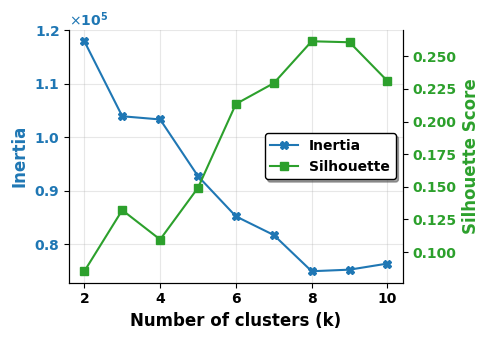


Best k by silhouette score: 8


In [17]:
fig, ax1 = plt.subplots(figsize=(5, 3.5))

font_labels = {'weight': 'bold', 'size': 12}
color1 = 'tab:blue'
ax1.set_xlabel('Number of clusters (k)', fontdict=font_labels)
ax1.set_ylabel('Inertia', color=color1, fontdict=font_labels)
line1 = ax1.plot(list(K_RANGE), inertias, marker='X', color=color1, label='Inertia')

ax1.tick_params(axis='y', labelcolor=color1)
ax1.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()  
color2 = 'tab:green'
ax2.set_ylabel('Silhouette Score', color=color2, fontdict=font_labels)
line2 = ax2.plot(list(K_RANGE), silhouette_scores, marker='s', color=color2, label='Silhouette')

ax2.tick_params(axis='y', labelcolor=color2)
ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f')) 

for ax in [ax1, ax2]:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(10)
    ax.spines['top'].set_visible(False)

ax1.yaxis.get_offset_text().set_fontweight('bold')
ax1.yaxis.get_offset_text().set_fontsize(10)

lines = line1 + line2
labels = [l.get_label() for l in lines]
leg = ax1.legend(
    lines, labels, 
    loc='center right', 
    fancybox=True, 
    shadow=True, 
    frameon=True, 
    prop={'weight': 'bold', 'size': 10}
)
leg.get_frame().set_edgecolor('black')

fig.tight_layout()  
plt.savefig('cluster_selection_sweep.pdf', bbox_inches='tight')
plt.show()

best_k_silhouette = list(K_RANGE)[np.argmax(silhouette_scores)]
print(f"\nBest k by silhouette score: {best_k_silhouette}")

In [18]:
SAMPLE_SIZE = 20000
plot_indices = np.random.choice(X_train.shape[0], size=SAMPLE_SIZE, replace=False)

X_train_plot = X_train[plot_indices]
clusters_plot = train_clusters[plot_indices]

runtimes_plot_hours = y_train[plot_indices] / 3600

tsne = TSNE(n_components=2, random_state=42, n_jobs=-1)
X_2d = tsne.fit_transform(X_train_plot)

plot_df = pd.DataFrame({
    'Component 1': X_2d[:, 0],
    'Component 2': X_2d[:, 1],
    'Cluster': clusters_plot,
    'Runtime (Hours)': runtimes_plot_hours
})
plot_df['Runtime (Hours)'] = plot_df['Runtime (Hours)'].clip(lower=1/3600)

In [19]:
def apply_tsne_aesthetics(ax):
    sns.despine(ax=ax)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(10)

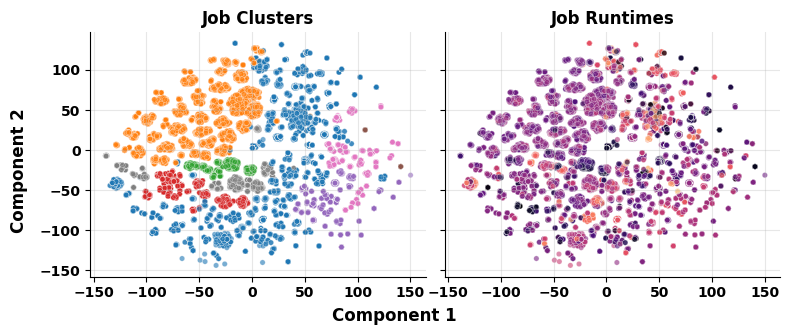

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), sharex=True, sharey=True)

sns.scatterplot(data=plot_df, x='Component 1', y='Component 2', hue='Cluster', palette='tab10', alpha=0.6, s=15, ax=axes[0], legend=False)
axes[0].set_title('Job Clusters', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('') 
axes[0].set_ylabel('') 
apply_tsne_aesthetics(axes[0])

sns.scatterplot(data=plot_df, x='Component 1', y='Component 2', hue='Runtime (Hours)', palette='magma', hue_norm=LogNorm(), alpha=0.6, s=15, ax=axes[1], legend=False)
axes[1].set_title('Job Runtimes', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('') 
axes[1].set_ylabel('') 
apply_tsne_aesthetics(axes[1])

font_labels = {'weight': 'bold', 'size': 12}

fig.supxlabel('Component 1', y=0.06, **font_labels)
fig.supylabel('Component 2', x=0.02, **font_labels)
plt.tight_layout(pad=1.0)
plt.savefig('clustering_tsne.pdf', bbox_inches='tight')
plt.show()